# **Asignatura**: Aprendizaje Automático

**Práctica 1**: Aprendizaje supervisado.

**Valoración máxima**: 10 puntos

**Fecha límite de entrega**: Ver PRADO.

**Procedimiento de entrega**: a través de PRADO

**Nombre completo**: Laura Salas López



**Normas de desarrollo y entrega de trabajos**

- Única y exclusivamente se debe entregar este Notebook de Colab (fichero `.ipynb`). **No es necesario entregar ninguna memoria externa**.

- El código debe estar bien comentado, y todas las decisiones tomadas y el trabajo desarrollado deben documentarse ampliamente en celdas de texto. **Sin esta documentación, se considera que el trabajo NO ha sido presentado**.

- Se debe respetar la estructura y secciones del Notebook.

- El código **NO debe escribir nada a disco**.

- Una entrega es apta para ser corregida si se puede ejecutar de principio a fin sin errores.


---

# **Ejercicio 1: Problema de Clasificación (5 puntos)**

## 1.1 Contexto: Clasificación de Gama de Móviles

Una empresa de tecnología quiere lanzar un nuevo modelo de teléfono móvil y necesita estimar en qué rango de precios colocarlo para competir en el mercado. Para ello, ha recopilado datos de ventas de diversos móviles con sus especificaciones técnicas.

**Objetivo:** Crear un modelo que clasifique un móvil en uno de los 4 rangos de precios basándose en sus características (RAM, batería, megapíxeles, etc.).

**Variable Objetivo (Target):**
- `price_range`: 0 (Bajo Coste), 1 (Coste Medio), 2 (Coste Alto), 3 (Coste Muy Alto).

**Principales Variables (Features):**
- `battery_power`: Energía total de batería en mAh.
- `ram`: Memoria de acceso aleatorio en Mb (suele ser la más determinante).
- `fc`: Megapíxeles de cámara frontal.
- `int_memory`: Memoria interna en Gb.
- `mobile_wt`: Peso del móvil.
- `touch_screen`: Si tiene pantalla táctil (1) o no (0).
- ... y otras especificaciones de hardware.

In [157]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   # para facilitar el representar algunos gráficos

# Herramientas de scikit-learn
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler, FunctionTransformer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

pd.set_option('display.max_columns', None)  # para que no corte las tablas al mostrarlas

# Carga de datos Clasificación (Mobile Price)
url='https://drive.google.com/file/d/1qciBzxaCwRV-LO-zueyQlBcgxiQtM_eI/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
df = pd.read_csv(url)


print("Datos de Móviles cargados:")
display(df.head())

Datos de Móviles cargados:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,14,1208,1212,1411,8,2,15,1,1,0,1


## 1.2 Análisis Exploratorio de Datos (EDA) y Preprocesado

Realice las siguientes tareas obligatorias:

1.  **Análisis de Variables:** Estudie qué variables tienen mayor correlación con el `price_range`. ¿Es la RAM la más importante? Visualícelo.
2.  **Valores Nulos y Outliers:** Compruebe la limpieza del dataset.
3.  **Escalado de Datos:** Dado que tenemos variables con rangos muy distintos (ej: `battery_power` en miles vs `clock_speed` decimal), es **obligatorio** escalar las características (StandardScaler/MinMaxScaler).
4.  **Selección de Características:** (Opcional) Puede intentar reducir la dimensionalidad o eliminar variables con baja correlación (ej. `three_g` o `touch_screen` si no afectan al precio).

In [158]:
# Extraemos las características (X) y las etiquetas (y)
X_raw = df.drop('price_range', axis=1).values
Y_raw = df['price_range'].values

print("Dimensiones de X: {} datos y {} atributos/dato".format(X_raw.shape[0], X_raw.shape[1]))

etiquetas= np.unique(Y_raw)

print("La última columna tiene la clase. Hay {} tipos de clase: {}".format(len(etiquetas), etiquetas))

Dimensiones de X: 2000 datos y 20 atributos/dato
La última columna tiene la clase. Hay 4 tipos de clase: [0 1 2 3]


In [159]:
print('Información básica del dataset: ')
df.info()

print('\nEstadísticos básicos: ')
df.describe()


Información básica del dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,9.916500,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,6.064315,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,5.000000,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,10.000000,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,15.000000,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,20.000000,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


Podemos ver que no hay valores nulos en ninguna de las columnas, por lo que no tendremos que tratar ese punto. También vemos que los rangos de las variables son muy distintos, por lo que habrá que escalar.

Primero voy a generar el diagrama de quesos, para ver si tenemos más o menos el mismo número de elementos de cada clase.

Recuento de muestras por clase:
price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64



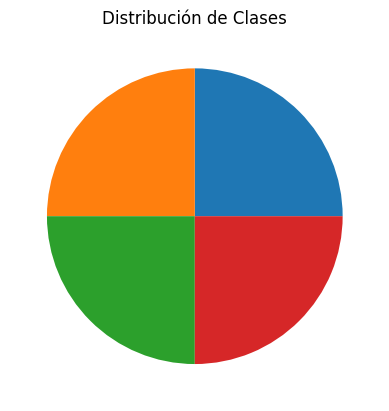

In [160]:
# diagrama de quesos
count_classes = df['price_range'].value_counts()
print(f"Recuento de muestras por clase:\n{count_classes}\n")

plt.figure()
plt.pie(count_classes)
plt.title('Distribución de Clases')
plt.show()

Como podemos ver, tenemos exactamente 500 elementos de cada tipo.

Ahora voy a ver qué variables tienen mayor correlación con `price_range`. Así como el heatmap de todas las variables entre ellas, para deducir posibles relaciones entre variables.

Correlación de las distintas variables con price_range:
price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


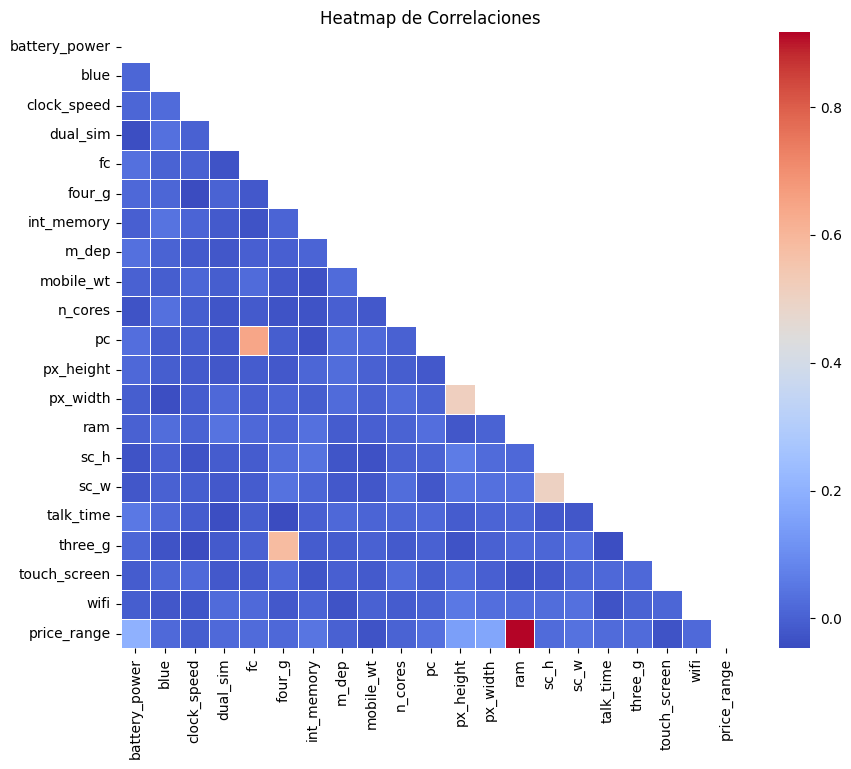

In [161]:
# matriz de correlación
matriz_corr = df.corr()
print("Correlación de las distintas variables con price_range:")
print(matriz_corr['price_range'].sort_values(ascending=False))

# heatmap
plt.figure(figsize=(10, 8))
# solo mostramos la mitad inferior del heatmap para que sea más limpio
mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
sns.heatmap(matriz_corr, mask=mask, annot=False, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap de Correlaciones')
plt.show()

Vemos que la `ram` es la variable con mayor correlación con nuestra variable objetivo `price_range`, seguida de `battery_power`, `px_width` y `px_height` (los píxeles del dispositivo), lo que me hace pensar que quizás considerar una variable nueva `pixeles_totales` (producto de estas dos anteriores) podría ser una buena opción, ya que además vemos que entre ellas tienen alta correlación también.

Otras variables con alta correlación entre ellas son `pc` y `fc` (las cámaras) y `sc_w` y `sc_h` (el tamaño de la pantalla). Sin embargo, estas no tienen alta correlación con `price_range`, por lo que no voy a considerar nuevas variables a partir de ellas, pues no creo que vayan a aportar nada.

In [162]:
df['pixeles_totales'] = df['px_height'] * df['px_width']

# comparo las correlaciones con el precio
print(f"Correlación px_height: {df['px_height'].corr(df['price_range']):.4f}")
print(f"Correlación px_width: {df['px_width'].corr(df['price_range']):.4f}")
print(f"Correlación pixeles_totales: {df['pixeles_totales'].corr(df['price_range']):.4f}")

Correlación px_height: 0.1489
Correlación px_width: 0.1658
Correlación pixeles_totales: 0.1762


Al obtener ahora una correlación mayor, me quedo con la nueva variable y elimino las otras dos, reduciendo en uno el número total de variables.

In [163]:
df = df.drop(['px_height', 'px_width'], axis=1)

Vamos ahora a visualizar algunas de las características (que pienso podrían ser más relevantes) con un boxplot para ver si hay outliers.

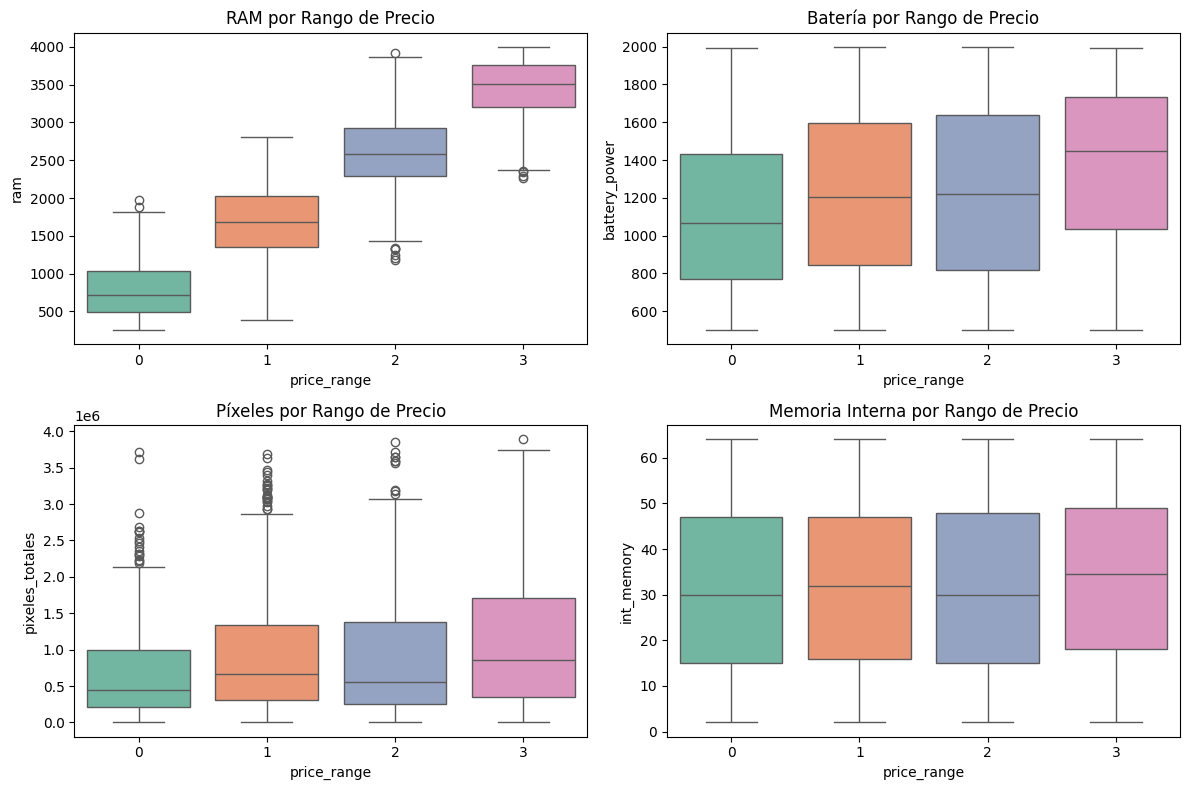

In [164]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes = axes.flatten()

# RAM
sns.boxplot(ax=axes[0], x='price_range', y='ram', data=df, hue='price_range', palette='Set2', legend=False)
axes[0].set_title('RAM por Rango de Precio')

# Batería
sns.boxplot(ax=axes[1], x='price_range', y='battery_power', data=df, hue='price_range', palette='Set2', legend=False)
axes[1].set_title('Batería por Rango de Precio')

# Píxeles
sns.boxplot(ax=axes[2], x='price_range', y='pixeles_totales', data=df, hue='price_range', palette='Set2', legend=False)
axes[2].set_title('Píxeles por Rango de Precio')

# Memoria Interna
sns.boxplot(ax=axes[3], x='price_range', y='int_memory', data=df, hue='price_range', palette='Set2', legend=False)
axes[3].set_title('Memoria Interna por Rango de Precio')


plt.tight_layout()
plt.show()

Vemos que tanto en `ram` como en `pixeles_totales` aparecen posibles outliers. Sin embargo, tomo la decisión de no eliminarlos porque son valores dentro del rango de valores posibles de la variable (no hay negativos ni números demasiado grandes). Asumo que las diferencias con respecto al resto de su clase se deben a las otras variables.

También podemos ver como la memoria RAM va subiendo con `price_range`, mientras que otras variables, como la memoria interna, se mantienen más o menos constantes aunque varíe el `price_range`. Esto nos da una idea de que, por ejemplo, la memoria interna no va a ser muy relevante a la hora de distinguir entre las posibles clases de precio, o al menos no por sí sola.

Ahora voy a realizar algunos diagramas de dispersión, a ver si me dan algo más de información.

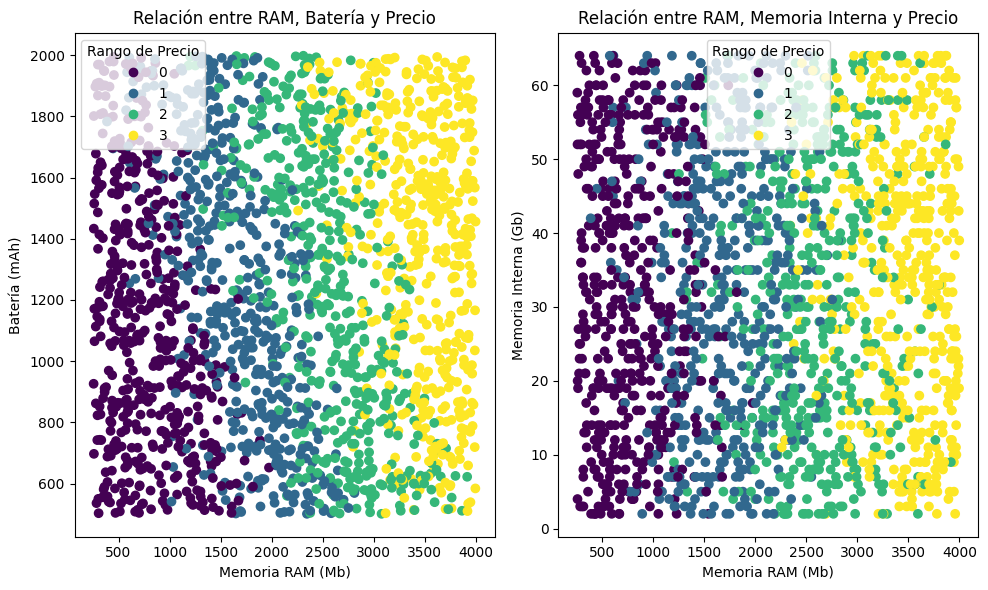

In [165]:
plt.figure(figsize=(10, 6))

# ram vs bateria
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(df['ram'], df['battery_power'], c=df['price_range'], cmap='viridis')
plt.title('Relación entre RAM, Batería y Precio')
plt.xlabel('Memoria RAM (Mb)')
plt.ylabel('Batería (mAh)')
plt.legend(*scatter1.legend_elements(), title='Rango de Precio')

# ram vs memoria interna
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(df['ram'], df['int_memory'], c=df['price_range'], cmap='viridis')
plt.title('Relación entre RAM, Memoria Interna y Precio')
plt.xlabel('Memoria RAM (Mb)')
plt.ylabel('Memoria Interna (Gb)')
plt.legend(*scatter2.legend_elements(), title='Rango de Precio')

plt.tight_layout()
plt.show()

En estos dos diagramas de dispersión podemos ver una ligera separación entre las clases, aunque hay solapamientos. Esto nos indica que vamos a necesitar varias variables del dataset para entrenar el modelo, con 2 o 3 solo no nos va a bastar para conseguir una separación entre clases.

Ahora divido los datos en train y test, usando `stratify=Y_raw` para que haya la misma proporción de cada tipo de móviles en train y en test. Una vez están divididos, escalo los datos para que no haya data leakage.

Para escalar los datos uso `StandardScaler` mejor que `MinMaxScaler` por los outliers de los que hemos hablado antes. Usando estandarización no nos van a afectar tanto esos valores extremos. Sin embargo, si usara la normalización sí que afectan mucho los números muy grandes o pequeños, pues son los que se toman con valor 0 y 1, y todos los otros valores, que son los realmente importantes, van a estar juntos en un rango pequeño de números.

In [166]:
# actualizamos X_raw tras las modificaciones de variables
X_raw = df.drop('price_range', axis=1).values

# Dividimos en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X_raw, Y_raw, test_size=0.2, random_state=42, stratify=Y_raw)

# Estandarización de datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Transformamos test con los parámetros de train

print(f"Media de X_train_scaled (por columna): {np.mean(X_train_scaled, axis=0).round(2)}")
print(f"Desviación estándar de X_train_scaled: {np.std(X_train_scaled, axis=0).round(2)}")

print(f"Tamaño de X_train: {X_train_scaled.shape}")
print(f"Tamaño de X_test: {X_test_scaled.shape}")


Media de X_train_scaled (por columna): [-0.  0. -0.  0. -0.  0.  0. -0.  0. -0. -0. -0.  0.  0. -0.  0. -0.  0.
 -0.]
Desviación estándar de X_train_scaled: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Tamaño de X_train: (1600, 19)
Tamaño de X_test: (400, 19)


Por último, antes de pasar al entrenamiento, voy a aplicar `SelectKBest` para ver cuáles son las características más relevantes en este problema y comprobar si coinciden con las ideas que hemos obtenido tras este análisis. Además, igual así podemos eliminar algunas características menos importantes antes de entrenar el modelo.

In [167]:
selector = SelectKBest(score_func=f_classif, k=10)

# entrenamos y transformamos
X_train_selected = selector.fit_transform(X_train_scaled, y_train)

# imprimimos las variables que ha seleccionado
nombres_variables = df.drop('price_range', axis=1).columns

puntuaciones = pd.DataFrame({
    'Variable': nombres_variables,
    'Puntuacion': selector.scores_
})

# ordenamos de mejor a peor
puntuaciones = puntuaciones.sort_values(by='Puntuacion', ascending=False)
print("Ranking de las variables segun SelectKBest:")
display(puntuaciones)

Ranking de las variables segun SelectKBest:


,Variable,Puntuacion
11,ram,2832.557774
0,battery_power,25.685266
18,pixeles_totales,17.780250
7,m_dep,3.654002
9,n_cores,2.951139
8,mobile_wt,2.878321
6,int_memory,2.400496
12,sc_h,2.115450
14,talk_time,1.598451
16,touch_screen,1.523159


Con esto podemos ver que variables que antes presentaban una correlación muy baja, como `m_dep`, sí que pueden ayudar en la clasificación.

Esto se debe a que antes hemos calculado el coeficiente de correlación de Pearson, una métrica útil para problemas de regresión, y ahora hemos usado la métrica `f_classif` de `SelectKBest`, que está diseñada para problemas de clasificación.

Igualmente, vemos una diferencia enorme entre `ram` y el resto de variables, por lo que esta sigue siendo la más importante.

Voy a crear variables solo con las 6 mejores características para eliminar ruido a la hora de entrenar modelos como KNN. Así, según el modelo a entrenar, puede que sea mejor usar solo esas 6 características o todas.

(Me quedo con las 6 mejores porque ya a partir de la séptima hay más cambio en la puntuación. Además, después he probado cambiando este parámetro y así obtengo los mejores resultados)

In [168]:
selector = SelectKBest(score_func=f_classif, k=6)
X_train_top6 = selector.fit_transform(X_train_scaled, y_train)
X_test_top6 = selector.transform(X_test_scaled)

print(f"Nuevas dimensiones de entrenamiento: {X_train_top6.shape}")

Nuevas dimensiones de entrenamiento: (1600, 6)


## 1.3 Entrenamiento y Validación (Clasificación Multiclase)

Pruebe al menos 2 modelos de clasificación (ej. KNN, Random Forest, SVM con kernel RBF).

- **Nota Importante:** Al ser un problema **multiclase** (4 clases), asegúrese de configurar las métricas adecuadamente (ej. `average='macro'` o `'weighted'`).
- **Métricas obligatorias:** Accuracy, Informe de Clasificación (Precision/Recall/F1 por clase) y Matriz de Confusión (Heatmap).

Para poder probar varios modelos de clasificación más rápidamente y poder compararlos entre ellos, voy a usar un dict con todos los modelos que quiero probar.

También voy a entrenar los modelos usando todas las características y usando solo el top6 que hemos obtenido en el paso anterior.

In [169]:
# Definimos los modelos
modelos = {
    "Árbol de Decisión": DecisionTreeClassifier(random_state=42),
    "Regresión Logística": LogisticRegression(random_state=42),
    "SVC (Kernel Lineal)": SVC(kernel='linear', random_state=42),
    "SVC (Kernel RBF)": SVC(kernel='rbf', random_state=42),
    "KNN (5 Vecinos)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=50)
}

# Definimos K-Fold con 5 particiones (folds)
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluamos los modelos
print("--- Resultados de Validación Cruzada (Precisión/Accuracy) ---")

resultados = {}

# Evaluamos cada modelo usando X_train_scaled (todas las variables)
for nombre, modelo in modelos.items():
    # Evaluamos usando cross_val_score
    scores = cross_val_score(modelo, X_train_scaled, y_train, cv=kfold, scoring='accuracy')

    # Guardamos la media para luego saber qué modelo es mejor
    resultados[nombre + " (X_train_scaled)"] = scores.mean()

    print(f"{nombre:20s} (X_train_scaled): {scores.mean():.4f} (+/- {scores.std():.4f})")


# Evaluamos cada modelo usando X_train_top6 (solo las 6 mejores variables)
for nombre, modelo in modelos.items():
    # Evaluamos usando cross_val_score
    scores = cross_val_score(modelo, X_train_top6, y_train, cv=kfold, scoring='accuracy')

    # Guardamos la media para luego saber qué modelo es mejor
    resultados[nombre+ " (X_train_top6)"] = scores.mean()

    print(f"{nombre:20s} (X_train_top6): {scores.mean():.4f} (+/- {scores.std():.4f})")

# Imprimimos los dos mejores modelos
modelos_ordenados = sorted(resultados, key=resultados.get, reverse=True)

mejor_modelo = modelos_ordenados[0]
segundo_mejor_modelo = modelos_ordenados[1]

print(f"\nEl mejor modelo es: {mejor_modelo} con un {resultados[mejor_modelo]*100:.2f}% de precisión.")
print(f"\nEl segundo mejor modelo es: {segundo_mejor_modelo} con un {resultados[segundo_mejor_modelo]*100:.2f}% de precisión.")



--- Resultados de Validación Cruzada (Precisión/Accuracy) ---
Árbol de Decisión    (X_train_scaled): 0.8356 (+/- 0.0183)
Regresión Logística  (X_train_scaled): 0.9250 (+/- 0.0143)
SVC (Kernel Lineal)  (X_train_scaled): 0.9250 (+/- 0.0195)
SVC (Kernel RBF)     (X_train_scaled): 0.8444 (+/- 0.0146)
KNN (5 Vecinos)      (X_train_scaled): 0.4806 (+/- 0.0273)
Random Forest        (X_train_scaled): 0.8475 (+/- 0.0246)
Árbol de Decisión    (X_train_top6): 0.8481 (+/- 0.0190)
Regresión Logística  (X_train_top6): 0.9281 (+/- 0.0099)
SVC (Kernel Lineal)  (X_train_top6): 0.9325 (+/- 0.0102)
SVC (Kernel RBF)     (X_train_top6): 0.9056 (+/- 0.0179)
KNN (5 Vecinos)      (X_train_top6): 0.7594 (+/- 0.0178)
Random Forest        (X_train_top6): 0.8812 (+/- 0.0186)

El mejor modelo es: SVC (Kernel Lineal) (X_train_top6) con un 93.25% de precisión.

El segundo mejor modelo es: Regresión Logística (X_train_top6) con un 92.81% de precisión.


Ahora que tenemos los dos modelos más prometedores (SVC con kernel lineal y Regresión Logística), hago la evaluación final usando el conjunto de test.

Podemos ver que estos modelos dan los mejores resultados en ambos casos, ya sea usando todas las variables disponibles, o solo el top 6. Sin embargo, usando solo el top 6 dan unos resultados un poco mejores. Esto se debe a que eliminamos el ruido producido por las otras variables, que no aportaban prácticamente nada. De hecho, para todos los modelos se obtienen mejores resultados usando solo esas 6 características.

Voy a realizar el entrenamiento final, comprobando la validez de los modelos sobre el conjunto de test. Antes, voy a aplicar GridSearchCV para intentar optimizar el hiperparámetro `C` (regularización) de ambos modelos. Ese valor de `C` es 1 por defecto y, cuanto mayor es este número, más estricto es el modelo.

--- SVC (Kernel Lineal) (X_train_top6) ---
Mejor valor encontrado para C: {'C': 10}
Precisión final en el conjunto de prueba: 93.75%



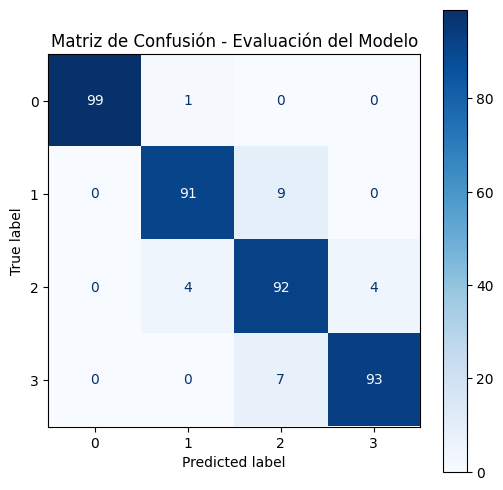

Report de modelo final:


,precision,recall,f1-score,support
0,1.00,0.99,0.99,100.00
1,0.95,0.91,0.93,100.00
2,0.85,0.92,0.88,100.00
3,0.96,0.93,0.94,100.00
accuracy,0.94,0.94,0.94,0.94
macro avg,0.94,0.94,0.94,400.00
weighted avg,0.94,0.94,0.94,400.00



--- Regresión Logística (X_train_top6) ---
Mejor valor encontrado para C: {'C': 100}
Precisión final en el conjunto de prueba: 94.75%



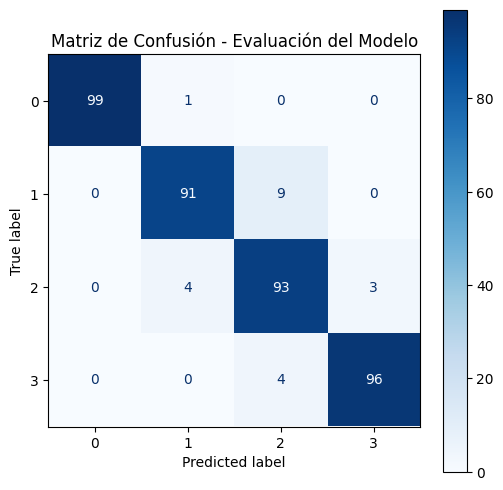

Report de modelo final:


,precision,recall,f1-score,support
0,1.00,0.99,0.99,100.00
1,0.95,0.91,0.93,100.00
2,0.88,0.93,0.90,100.00
3,0.97,0.96,0.96,100.00
accuracy,0.95,0.95,0.95,0.95
macro avg,0.95,0.95,0.95,400.00
weighted avg,0.95,0.95,0.95,400.00


In [170]:
from sklearn.model_selection import GridSearchCV

# Entrenamiento final

# SVC (Kernel Lineal) (X_train_top6)
print("--- SVC (Kernel Lineal) (X_train_top6) ---")

# Definimos el hiperparámetro a optimizar
param_grid_svc = {
    'C': [0.1, 1, 10, 100]
}

# Configuramos el GridSearchCV
grid_svc = GridSearchCV(SVC(kernel='linear', random_state=42), param_grid_svc, cv=5, scoring='accuracy', n_jobs=-1)

# Entrenamos el Grid
grid_svc.fit(X_train_top6, y_train)

print(f"Mejor valor encontrado para C: {grid_svc.best_params_}")

# Extraemos el mejor modelo para predecir
modelo_final_1 = grid_svc.best_estimator_

# Predicción sobre el conjunto de prueba
y_pred = modelo_final_1.predict(X_test_top6)

# Validación (Métricas)
precision_final = accuracy_score(y_test, y_pred)
print(f"Precisión final en el conjunto de prueba: {precision_final * 100:.2f}%\n")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Graficamos la matriz
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Evaluación del Modelo')
plt.show()

# Classification report
report_final= classification_report(y_test, y_pred, output_dict=True)

# Convertimos a DataFrame y transponemos para que las métricas sean columnas
print('Report de modelo final:')
df_final = pd.DataFrame(report_final).transpose()
display(df_final.round(2))


# Regresión Logística (X_train_top6)
print("\n--- Regresión Logística (X_train_top6) ---")

# Definimos el hiperparámetro a optimizar
param_grid_lr = {
    'C': [0.1, 1, 10, 100]
}

# Configuramos el GridSearchCV
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1)

# Entrenamos el Grid
grid_lr.fit(X_train_top6, y_train)

print(f"Mejor valor encontrado para C: {grid_lr.best_params_}")

# Extraemos el mejor modelo para predecir
modelo_final_2 = grid_lr.best_estimator_

# Predicción sobre el conjunto de prueba
y_pred = modelo_final_2.predict(X_test_top6)

# Validación (Métricas)
precision_final = accuracy_score(y_test, y_pred)
print(f"Precisión final en el conjunto de prueba: {precision_final * 100:.2f}%\n")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Graficamos la matriz
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Evaluación del Modelo')
plt.show()

# Classification report
report_final= classification_report(y_test, y_pred, output_dict=True)

# Convertimos a DataFrame y transponemos para que las métricas sean columnas
print('Report de modelo final:')
df_final = pd.DataFrame(report_final).transpose()
display(df_final.round(2))

--- SVC (Kernel Lineal) (X_train_top6) ---
Precisión final en el conjunto de prueba: 95.75%



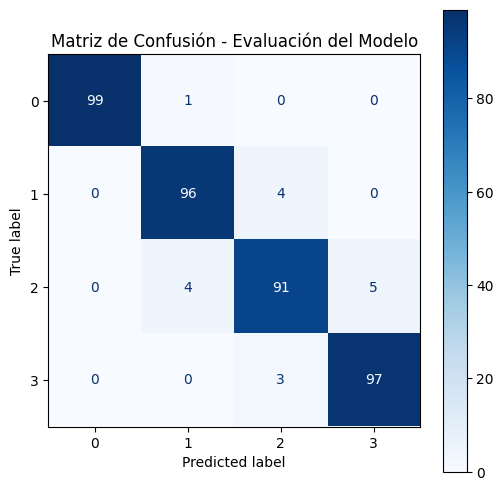

Report de modelo final:


,precision,recall,f1-score,support
0,1.00,0.99,0.99,100.00
1,0.95,0.96,0.96,100.00
2,0.93,0.91,0.92,100.00
3,0.95,0.97,0.96,100.00
accuracy,0.96,0.96,0.96,0.96
macro avg,0.96,0.96,0.96,400.00
weighted avg,0.96,0.96,0.96,400.00



--- Regresión Logística (X_train_top6) ---
Precisión final en el conjunto de prueba: 95.00%



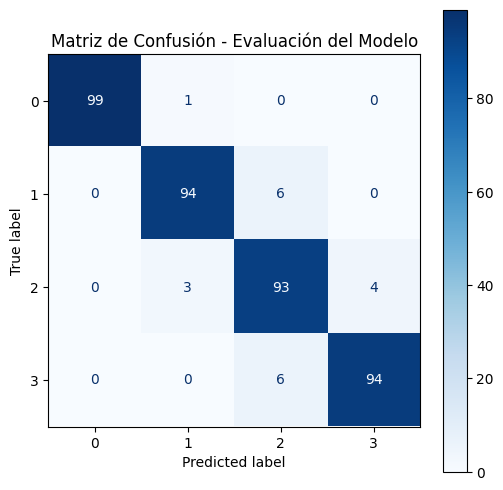

Report de modelo final:


,precision,recall,f1-score,support
0,1.00,0.99,0.99,100.00
1,0.96,0.94,0.95,100.00
2,0.89,0.93,0.91,100.00
3,0.96,0.94,0.95,100.00
accuracy,0.95,0.95,0.95,0.95
macro avg,0.95,0.95,0.95,400.00
weighted avg,0.95,0.95,0.95,400.00


In [171]:
# Entrenamos los mismos modelos sin GridSearchCV

# SVC (Kernel Lineal) (X_train_top6)
print("--- SVC (Kernel Lineal) (X_train_top6) ---")

modelo_final_1 = SVC(kernel='linear', random_state=42)
modelo_final_1.fit(X_train_top6, y_train)

# Predicción sobre el conjunto de prueba
y_pred = modelo_final_1.predict(X_test_top6)

# Validación (Métricas)
precision_final = accuracy_score(y_test, y_pred)
print(f"Precisión final en el conjunto de prueba: {precision_final * 100:.2f}%\n")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Graficamos la matriz
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Evaluación del Modelo')
plt.show()

# Classification report
report_final= classification_report(y_test, y_pred, output_dict=True)

# Convertimos a DataFrame y transponemos para que las métricas sean columnas
print('Report de modelo final:')
df_final = pd.DataFrame(report_final).transpose()
display(df_final.round(2))


# Regresión Logística (X_train_top6)
print("\n--- Regresión Logística (X_train_top6) ---")

modelo_final_2 = LogisticRegression(random_state=42)
modelo_final_2.fit(X_train_top6, y_train)

# Predicción sobre el conjunto de prueba
y_pred = modelo_final_2.predict(X_test_top6)

# Validación (Métricas)
precision_final = accuracy_score(y_test, y_pred)
print(f"Precisión final en el conjunto de prueba: {precision_final * 100:.2f}%\n")

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Graficamos la matriz
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Evaluación del Modelo')
plt.show()

# Classification report
report_final= classification_report(y_test, y_pred, output_dict=True)

# Convertimos a DataFrame y transponemos para que las métricas sean columnas
print('Report de modelo final:')
df_final = pd.DataFrame(report_final).transpose()
display(df_final.round(2))

Finalmente, vemos que los modelos con sus hiperparámetros por defecto obtienen mejores resultados sobre el conjunto de test.

Al aplicar `GridSearchCV` en SVC obtengo que el mejor valor es `C=10`. Sin embargo, al validar con el conjunto de test obtengo una precisión de 93.75%, frente al 95.75% que obtengo con los parámetros por defecto, sin utilizar `GridSearchCV`. Lo mismo pasa en la Regresión Logística, obtengo que el mejor valor es `C=100` con una precisión de 94.75%, pero sin `GridSearchCV` obtengo un 95% de precisión.

En ambos casos esto se debe al overfitting. Al aumentar el valor de `C`, el modelo penaliza más los errores en el conjunto de entrenamiento, ajustandose demasiado a este conjunto de datos y, al probar con el conjunto de test, que no ha visto nunca, comete más errores.

## **Conclusiones Generales**

El mejor modelo que he encontrado es `SVC` usando el kernel lineal y las 6 mejores variables seleccionadas por `SelectKBest`. Sin embargo, hay muy poca diferencia entre este modelo y el de `Regresión Logística`.

Se trata de dos modelos bastante simples (teniendo en cuenta que hemos probado otros como Random Forest, bastante más complejo) y funcionan tan bien en este caso porque tenemos una varible, `ram`, con una correlación lineal de casi 0.92 con nuestra variable objetivo, por lo que, al subir la RAM, el precio sube casi proporcionalmente. Como ambos modelos son lineales, vienen muy bien en esta situación.

Además, como he dicho antes, en todos los modelos se obtienen mejores resultados usando menos variables, pues muchas de las variables que tenemos solo aportan ruido y prácticamente no son relevantes para categorizar el precio.

---

# **Ejercicio 2: Problema de Regresión (5 puntos)**

## 2.1 Contexto: Predicción de la Resistencia del Hormigón

En ingeniería civil, la resistencia a la compresión del hormigón es una función compleja de su edad y sus ingredientes. En este ejercicio, deberá desarrollar un modelo de regresión para **predecir la resistencia (en MegaPascales, MPa)** basándose en la composición de la mezcla.

**Dataset:** Concrete Compressive Strength Data Set (UCI Machine Learning Repository).

- **Variables de Entrada (X):** Cemento, Escoria, Ceniza, Agua, Superplastificante, Árido grueso, Árido fino, Edad (días).
- **Variable de Salida (Y):** Resistencia a la compresión del hormigón (MPa).


In [172]:
# Carga de datos Regresión
url= 'https://drive.google.com/file/d/1mlzSDAUlXMMTjL7PbpXJQddHKAyZeYft/view?usp=sharing'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]

df_reg = pd.read_csv(url)

print("Datos de Regresión cargados:")
display(df_reg.head())

Datos de Regresión cargados:


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


## 2.2 Análisis y Preprocesado (Regresión)

Prepare los datos para el modelado:
1.  Estudie la distribución de la variable objetivo (`strength`).
2.  Analice la correlación de las variables de entrada con la salida.
3.  Aplique el escalado necesario a las variables independientes.

Empiezo buscando obtener algo más de información del dataset.

In [173]:
print('Información básica del dataset: ')
df_reg.info()

print('\nEstadísticos básicos: ')
df_reg.describe()

Información básica del dataset: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB

Estadísticos básicos: 


,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


Podemos ver que no hay valores nulos, por lo que no tendremos que tratarlos. Por otro lado, los datos toman rangos de valores muy distintos, por lo que habrá que escalarlos.

Voy a pintar el histograma de `strength` para ver cómo se distribuye la resistencia.

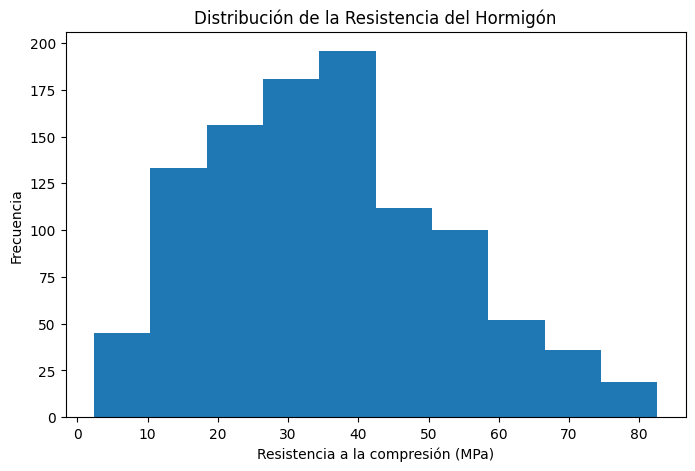

In [174]:
plt.figure(figsize=(8, 5))
plt.hist(df_reg['strength'], bins=10)
plt.title("Distribución de la Resistencia del Hormigón")
plt.xlabel('Resistencia a la compresión (MPa)')
plt.ylabel('Frecuencia')
plt.show()

Como podemos ver, la gráfica está ladeada para la izquierda. Respecto a los datos, esto nos indica que tenemos más casos de poca resistencia que de mucha. Respecto a los modelos, en los lineales como `Regresión Lineal` y `SVR` esto nos afecta, pues estos modelos asumen distribución normal.

Voy ahora a estudiar la correlación de las distintas variables con nuestra variable objetivo, así como el heatmap de todas las variables entre ellas.

Correlación de las distintas variables con strength:
strength        1.000000
cement          0.497832
superplastic    0.366079
age             0.328873
slag            0.134829
ash            -0.105755
coarseagg      -0.164935
fineagg        -0.167241
water          -0.289633
Name: strength, dtype: float64


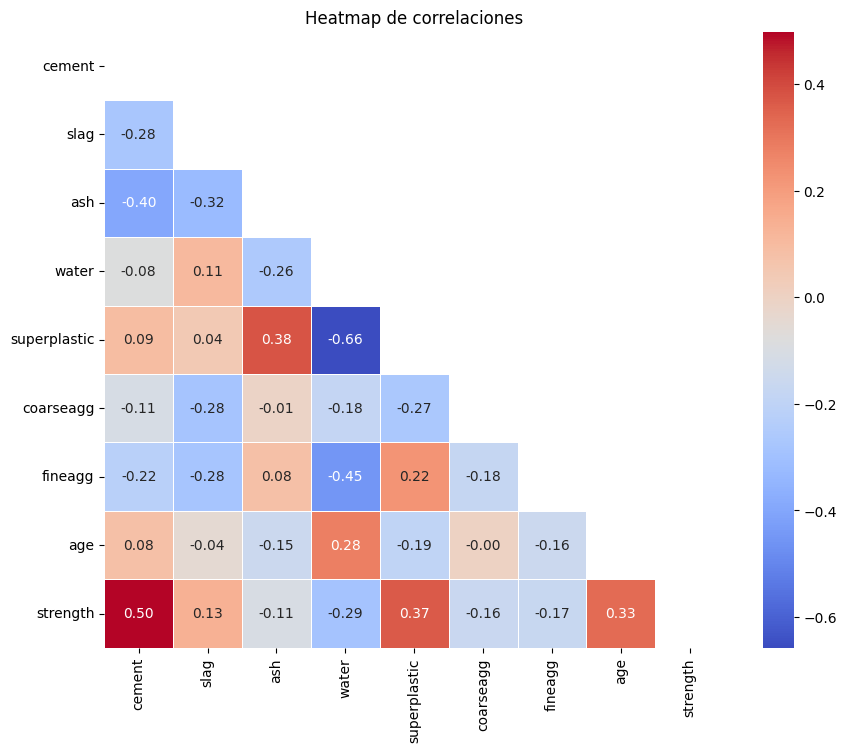

In [175]:
# matriz de correlación
matriz_corr_reg = df_reg.corr()

print("Correlación de las distintas variables con strength:")
print(matriz_corr_reg['strength'].sort_values(ascending=False))

# heatmap
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(matriz_corr_reg, dtype=bool))
sns.heatmap(matriz_corr_reg, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap de correlaciones')
plt.show()

Como podemos observar, las variables con mayor correlación con `strength` son `cement`, `superplastic`, `age` y `water`. Además, hay variables de entrada con alta correlación entre ellas, como `superplastic` y `water`.

Voy a visualizar ahora un boxplot con todas las variables para ver si tenemos outliers. Además, al tener todas las variables en el mismo gráfico vamos a ver las diferencias que nos obligan a escalar.

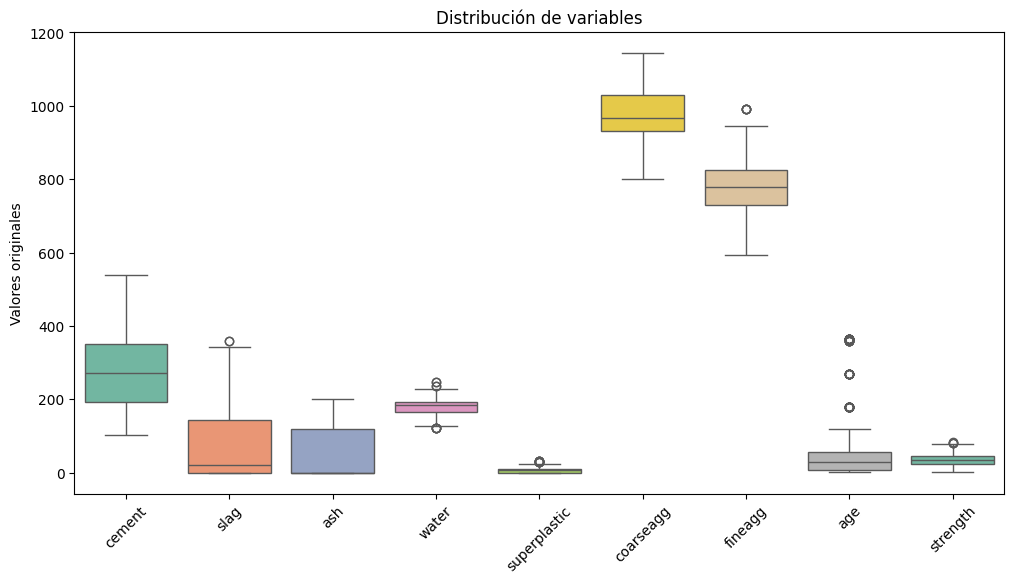

In [176]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_reg, palette='Set2')
plt.title('Distribución de variables')
plt.xticks(rotation=45)
plt.ylabel('Valores originales')
plt.show()

Respecto a los outliers, en `age` es donde podemos plantearnos si los valores extremos son outliers. Sin embargo, el máximo de edad es 365 días, 1 año, por lo que tampoco es un valor extraño. Simplemente indica que el hormiǵon ha estado un año formado antes de probarse. Por tanto, no elimino valores de ninguna de la variables, considero que todos están dentro del rango de valores aceptable correspondiente a cada variable.

Voy a pintar ahora algunos scatter plots con las variables que nos han salido con mayor correlación con `strength`.

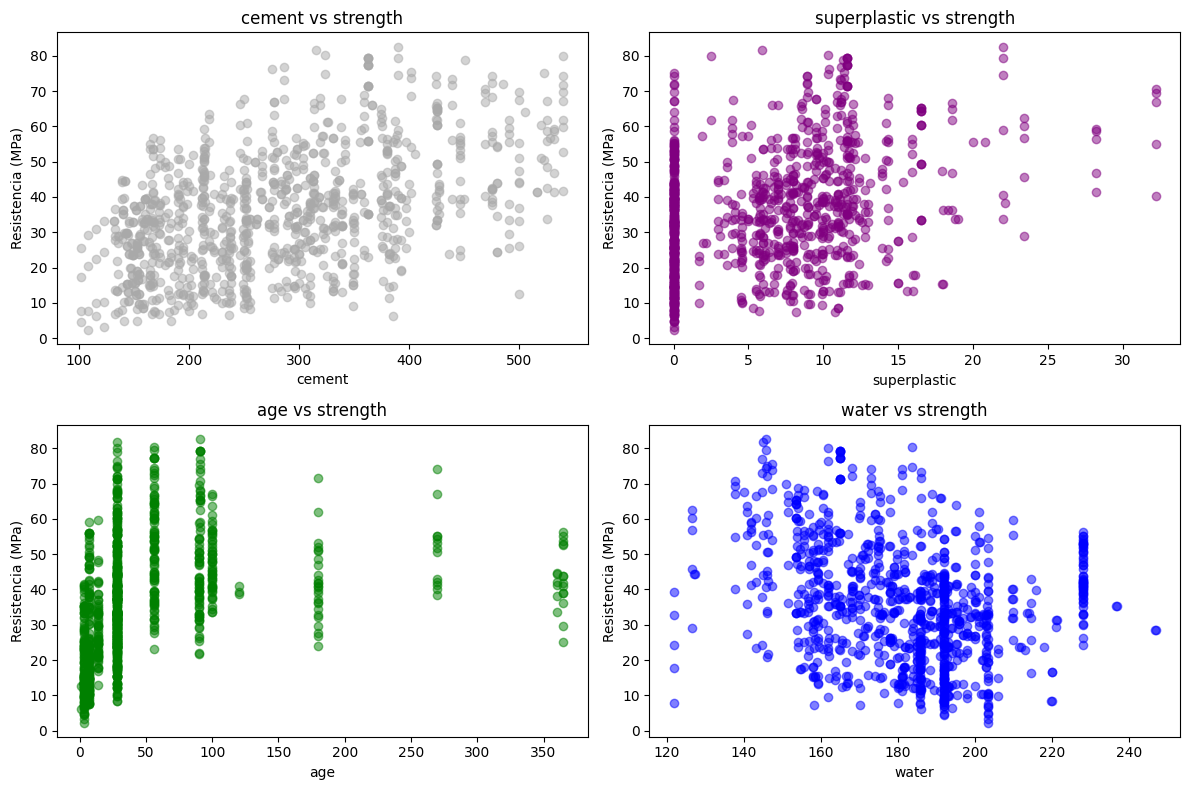

In [177]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

top_vars = ['cement', 'superplastic', 'age', 'water']
colores = ['darkgray', 'purple', 'green', 'blue']

for i, var in enumerate(top_vars):
    axes[i].scatter(df_reg[var], df_reg['strength'], alpha=0.5, color=colores[i])
    axes[i].set_title(f'{var} vs strength')
    axes[i].set_xlabel(f'{var}')
    axes[i].set_ylabel('Resistencia (MPa)')

plt.tight_layout()
plt.show()

En las gráficas podemos ver, por ejemplo, que en la del cemento hay una ligera tendencia hacia arriba y en la del agua hacia abajo, coincidiendo con los cálculos de correlación que hemos hecho antes. Además, vemos que para `age` solo tenemos unos determinados valores y que para `superplastic` hay muchos datos con valor 0, pero los que tienen un valor alto tienden a tener bastante resistencia también.

Ahora voy a escalar los datos. Al igual que en el ejercicio 1, los "outliers" que vemos en el boxplot hacen que sea mejor aplicar el `StandardScaler`.

In [178]:
# Extraemos las características (X) y las etiquetas (y)
X_raw_reg = df_reg.drop('strength', axis=1).values
Y_raw_reg = df_reg['strength'].values

# Dividimos en conjunto de entrenamiento (80%) y prueba (20%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_raw_reg, Y_raw_reg, test_size=0.2, random_state=42)

# Estandarización de datos
scaler = StandardScaler()
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg) # Transformamos test con los parámetros de train

print(f"Media de X_train_scaled (por columna): {np.mean(X_train_reg_scaled, axis=0).round(2)}")
print(f"Desviación estándar de X_train_scaled: {np.std(X_train_reg_scaled, axis=0).round(2)}")

print(f"Tamaño de X_train: {X_train_reg_scaled.shape}")
print(f"Tamaño de X_test: {X_test_reg_scaled.shape}")


Media de X_train_scaled (por columna): [ 0. -0.  0. -0.  0.  0.  0.  0.]
Desviación estándar de X_train_scaled: [1. 1. 1. 1. 1. 1. 1. 1.]
Tamaño de X_train: (824, 8)
Tamaño de X_test: (206, 8)


## 2.3 Modelado y Evaluación (Regresión)

Entrene al menos 2 modelos de regresión (ej. Regresión Lineal, SVR, Gradient Boosting...).

**Métricas obligatorias:**
- MSE (Mean Squared Error)
- R2 Score (Coeficiente de determinación)
- MAE (Mean Absolute Error)

Incluya una gráfica de dispersión: Valores Reales (eje X) vs Valores Predichos (eje Y).

Al igual que en el ejercicio 1, primero voy a probar varios modelos a ver cual da mejores resultados con la validación cruzada. Luego me quedo los dos mejores y los entreno y evaluo con el conjunto de datos de test.

In [179]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Definimos los modelos
modelos_reg = {
    "Regresión Lineal": LinearRegression(),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

# Definimos K-Fold con 5 particiones (folds)
kfold_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Evaluamos los modelos
print("--- Resultados de Validación Cruzada (R2 Score) ---")

resultados_reg = {}

# Evaluamos cada modelo usando X_train_reg_scaled
for nombre, modelo in modelos_reg.items():
    # Evaluamos usando cross_val_score
    scores = cross_val_score(modelo, X_train_reg_scaled, y_train_reg, cv=kfold_reg, scoring='r2')

    # Guardamos la media para luego saber qué modelo es mejor
    resultados_reg[nombre] = scores.mean()

    print(f"{nombre:20s}: {scores.mean():.4f} (+/- {scores.std():.4f})")


# Imprimimos los dos mejores modelos
modelos_ordenados_reg = sorted(resultados_reg, key=resultados_reg.get, reverse=True)

mejor_modelo_reg = modelos_ordenados_reg[0]
segundo_mejor_modelo_reg = modelos_ordenados_reg[1]

print(f"\nEl mejor modelo es: {mejor_modelo_reg} con un R2 del {resultados_reg[mejor_modelo_reg]*100:.2f}%")
print(f"\nEl segundo mejor modelo es: {segundo_mejor_modelo_reg} con un R2 del {resultados_reg[segundo_mejor_modelo_reg]*100:.2f}%")




--- Resultados de Validación Cruzada (R2 Score) ---
Regresión Lineal    : 0.5971 (+/- 0.0473)
SVR                 : 0.6266 (+/- 0.0225)
Random Forest       : 0.8981 (+/- 0.0161)
Gradient Boosting   : 0.8913 (+/- 0.0171)

El mejor modelo es: Random Forest con un R2 del 89.81%

El segundo mejor modelo es: Gradient Boosting con un R2 del 89.13%


Como habíamos predicho antes, los modelos lineales no funcionan bien en este caso.

Hago por tanto la evaluación final con `Random Forest` y `Gradient Boosting`. Al igual que en el ejercicio 1, pruebo primero a ver si obtenemos mejores resultados variando los hiperparámetros con `GridSearchCV`. En este caso, los hiperparámetros a optimizar van a ser el número de árboles (`n_estimators`) y la profundidad máxima (`max_depth`).

--- Random Forest ---
Mejores hiperparámetros encontrados: {'max_depth': 20, 'n_estimators': 250}
MSE (Error Cuadrático Medio): 30.55
MAE (Error Absoluto Medio): 3.78
R2 Score: 88.14%



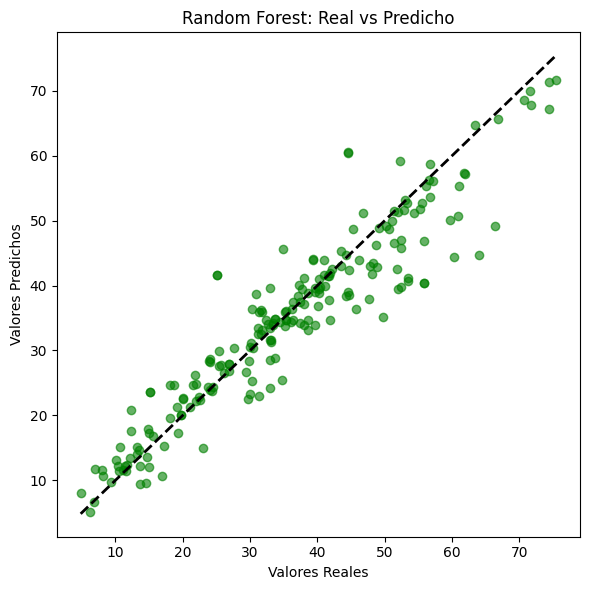


--- Gradient Boosting ---
Mejores hiperparámetros encontrados: {'max_depth': 10, 'n_estimators': 250}
MSE (Error Cuadrático Medio): 39.82
MAE (Error Absoluto Medio): 3.92
R2 Score: 84.55%



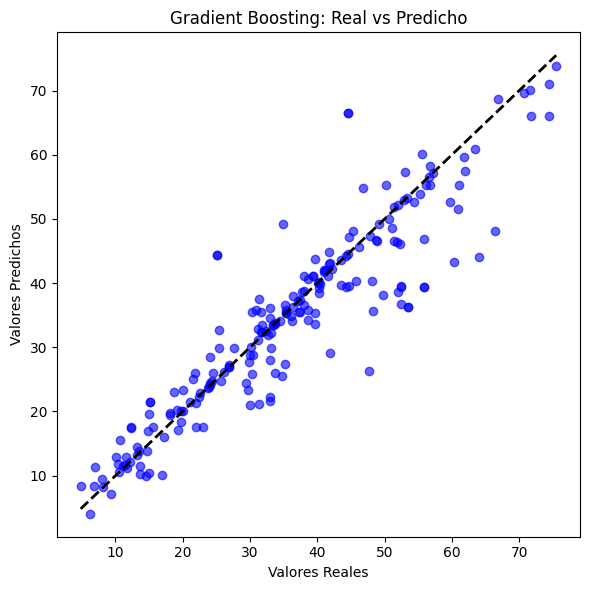

In [180]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Entrenamiento final

# Parámetros a probar (los mismos para ambos modelos pues los dos vienen de árboles)
param_grid = {
    'n_estimators': [50, 100, 200, 250],
    'max_depth': [None, 10, 20, 30]
}

# Random Forest
print("--- Random Forest ---")

# Configuramos el grid
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)

# Entrenamos
grid_rf.fit(X_train_reg_scaled, y_train_reg)

print(f"Mejores hiperparámetros encontrados: {grid_rf.best_params_}")

# Extraemos el mejor modelo
modelo_final_rf = grid_rf.best_estimator_

# Predicción sobre el conjunto de prueba
y_pred_1 = modelo_final_rf.predict(X_test_reg_scaled)

# Métricas
print(f"MSE (Error Cuadrático Medio): {mean_squared_error(y_test_reg, y_pred_1):.2f}")
print(f"MAE (Error Absoluto Medio): {mean_absolute_error(y_test_reg, y_pred_1):.2f}")
print(f"R2 Score: {r2_score(y_test_reg, y_pred_1) * 100:.2f}%\n")

# Gráfico: Valores Reales vs Predichos
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_1, alpha=0.6, color='green')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2) # Línea ideal
plt.title('Random Forest: Real vs Predicho')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.tight_layout()
plt.show()


# Gradient Boosting
print("\n--- Gradient Boosting ---")

# Configuramos el grid
grid_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)

# Entrenamos
grid_gb.fit(X_train_reg_scaled, y_train_reg)

print(f"Mejores hiperparámetros encontrados: {grid_gb.best_params_}")

# Extraemos el mejor modelo
modelo_final_gb = grid_gb.best_estimator_

# Predicción sobre el conjunto de prueba
y_pred_2 = modelo_final_gb.predict(X_test_reg_scaled)

# Métricas
print(f"MSE (Error Cuadrático Medio): {mean_squared_error(y_test_reg, y_pred_2):.2f}")
print(f"MAE (Error Absoluto Medio): {mean_absolute_error(y_test_reg, y_pred_2):.2f}")
print(f"R2 Score: {r2_score(y_test_reg, y_pred_2) * 100:.2f}%\n")

# Gráfico: Valores Reales vs Predichos
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_2, alpha=0.6, color='blue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2)
plt.title('Gradient Boosting: Real vs Predicho')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.tight_layout()
plt.show()

--- Random Forest ---
MSE (Error Cuadrático Medio): 29.85
MAE (Error Absoluto Medio): 3.73
R2 Score: 88.42%



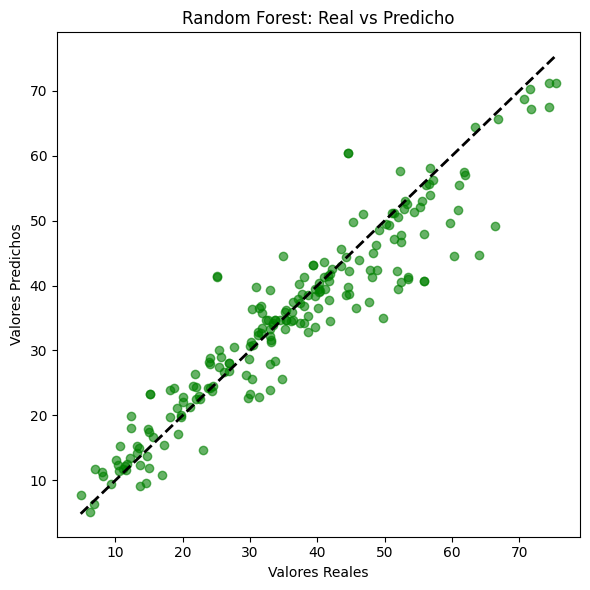


--- Gradient Boosting ---
MSE (Error Cuadrático Medio): 30.18
MAE (Error Absoluto Medio): 4.14
R2 Score: 88.29%



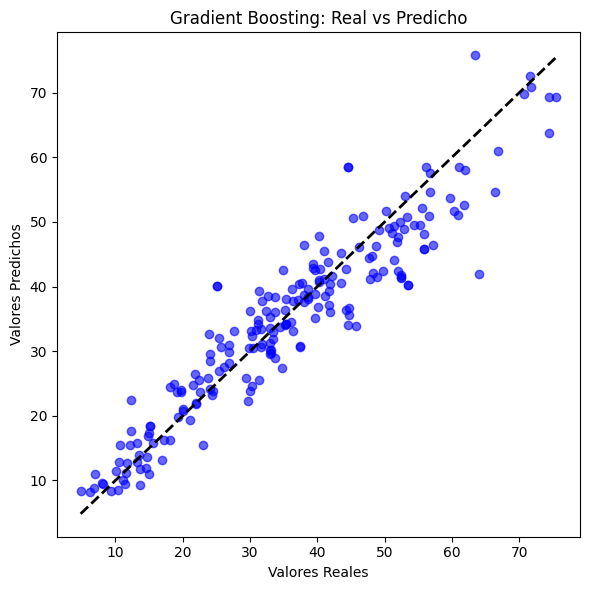

In [181]:
# Probamos a entrenar los mismos modelos pero sin GridSearchCV

# Random Forest
print("--- Random Forest ---")

modelo_final_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_final_rf.fit(X_train_reg_scaled, y_train_reg)

# Predicción sobre el conjunto de prueba
y_pred_1 = modelo_final_rf.predict(X_test_reg_scaled)

# Métricas
print(f"MSE (Error Cuadrático Medio): {mean_squared_error(y_test_reg, y_pred_1):.2f}")
print(f"MAE (Error Absoluto Medio): {mean_absolute_error(y_test_reg, y_pred_1):.2f}")
print(f"R2 Score: {r2_score(y_test_reg, y_pred_1) * 100:.2f}%\n")

# Gráfico: Valores Reales vs Predichos
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_1, alpha=0.6, color='green')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2) # Línea ideal
plt.title('Random Forest: Real vs Predicho')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.tight_layout()
plt.show()


# Gradient Boosting
print("\n--- Gradient Boosting ---")

modelo_final_gb = GradientBoostingRegressor(random_state=42)
modelo_final_gb.fit(X_train_reg_scaled, y_train_reg)

# Predicción sobre el conjunto de prueba
y_pred_2 = modelo_final_gb.predict(X_test_reg_scaled)

# Métricas
print(f"MSE (Error Cuadrático Medio): {mean_squared_error(y_test_reg, y_pred_2):.2f}")
print(f"MAE (Error Absoluto Medio): {mean_absolute_error(y_test_reg, y_pred_2):.2f}")
print(f"R2 Score: {r2_score(y_test_reg, y_pred_2) * 100:.2f}%\n")

# Gráfico: Valores Reales vs Predichos
plt.figure(figsize=(6, 6))
plt.scatter(y_test_reg, y_pred_2, alpha=0.6, color='blue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2)
plt.title('Gradient Boosting: Real vs Predicho')
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.tight_layout()
plt.show()

Igual que pasó en el ejercicio 1, usar `GridSearchCV` no mejora las métricas del conjunto de test.

En este caso, los valores tomados como óptimos han sido `max_depth = 10 o 20` y `n_estimators = 250`, provocando overfitting.

---

## **Conclusiones Generales**

Aunque obtenemos resultados muy parecidos, `Random Forest` da resultados algo mejores.

Con un R2 del 88.42%, tenemos que se explica más del 88% de la variabilidad. Además, el error es de +- 3.73 MPa, muy poco teniendo en cuenta que la mayoría de los datos van de 10 a 60 MPa.

Como ya hemos dicho, en este caso los modelos basados en árboles de decisión funcionan mejor que los lineales, pues no tenemos una distribución normal y, además, variables como `age` no son continuas, pues solo toma unos determinados valores.